In [1]:
#create a unique fasta file for the generate -peptide
from Bio import SeqIO

def remove_duplicates(input_fasta, output_fasta):
    # Read sequences from the input FASTA file
    records = list(SeqIO.parse(input_fasta, "fasta"))

    # Create a set to store unique sequences
    unique_sequences = set()

    # Filter out duplicates and add to the set
    filtered_records = []
    for record in records:
        sequence = str(record.seq)
        if sequence not in unique_sequences:
            unique_sequences.add(sequence)
            filtered_records.append(record)

    # Save unique sequences to the output FASTA file
    SeqIO.write(filtered_records, output_fasta, "fasta")

if __name__ == "__main__":
    # Specify the path to your input FASTA file
    input_path = "NON_ACP_GAN_300.fasta"

    # Specify the path for the output FASTA file (new.fasta)
    output_path = "Non_ACP_GAN_filtered_300.fasta"

    # Remove duplicates and save unique sequences
    remove_duplicates(input_path, output_path)

    print(f"Unique sequences saved to {output_path}")

Unique sequences saved to Non_ACP_GAN_filtered_300.fasta


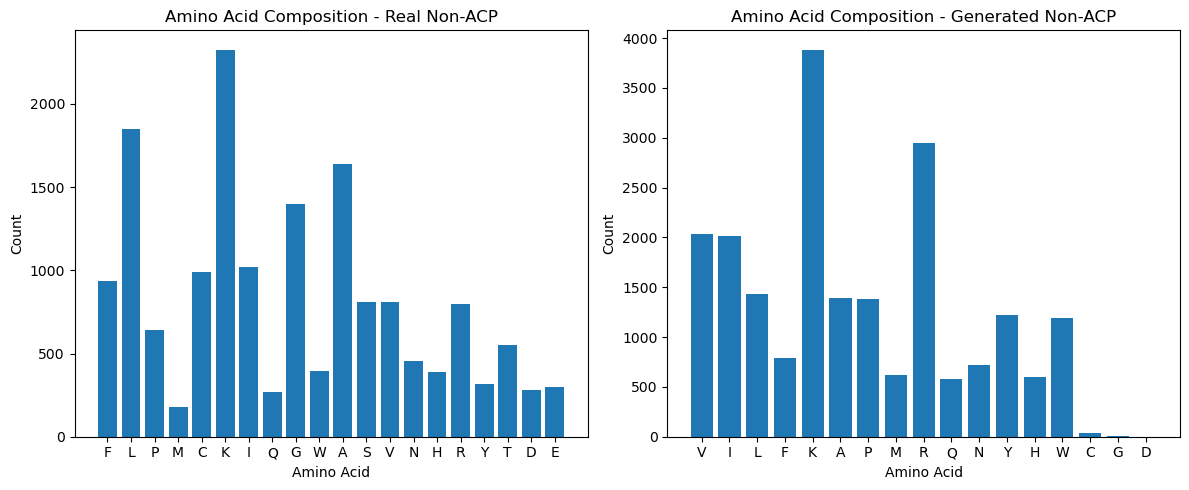

In [2]:
#compsotion analysis for THE amp
#composition analysis for the gan generated ACP and real ACP and AMP and GAN genertaed AMP
from Bio import SeqIO
import matplotlib.pyplot as plt

def plot_amino_acid_composition(ax, fasta_file, title):
    amino_acid_count = {}

    # Read sequences from the FASTA file
    sequences = [str(record.seq) for record in SeqIO.parse(fasta_file, "fasta")]

    # Count the occurrences of each amino acid
    for sequence in sequences:
        for amino_acid in sequence:
            amino_acid_count[amino_acid] = amino_acid_count.get(amino_acid, 0) + 1

    # Plot the amino acid composition
    labels, counts = zip(*amino_acid_count.items())
    ax.bar(labels, counts)
    ax.set_xlabel('Amino Acid')
    ax.set_ylabel('Count')
    ax.set_title(title)

# Replace file paths with the actual paths to your FASTA files
fasta_file_path1 = 'acp_pos_train.fasta'
fasta_file_path2 = 'ACP_GAN_300.fasta'

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot amino acid composition for the first file
plot_amino_acid_composition(axes[0], fasta_file_path1, 'Amino Acid Composition - Real Non-ACP')

# Plot amino acid composition for the second file
plot_amino_acid_composition(axes[1], fasta_file_path2, 'Amino Acid Composition - Generated Non-ACP')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

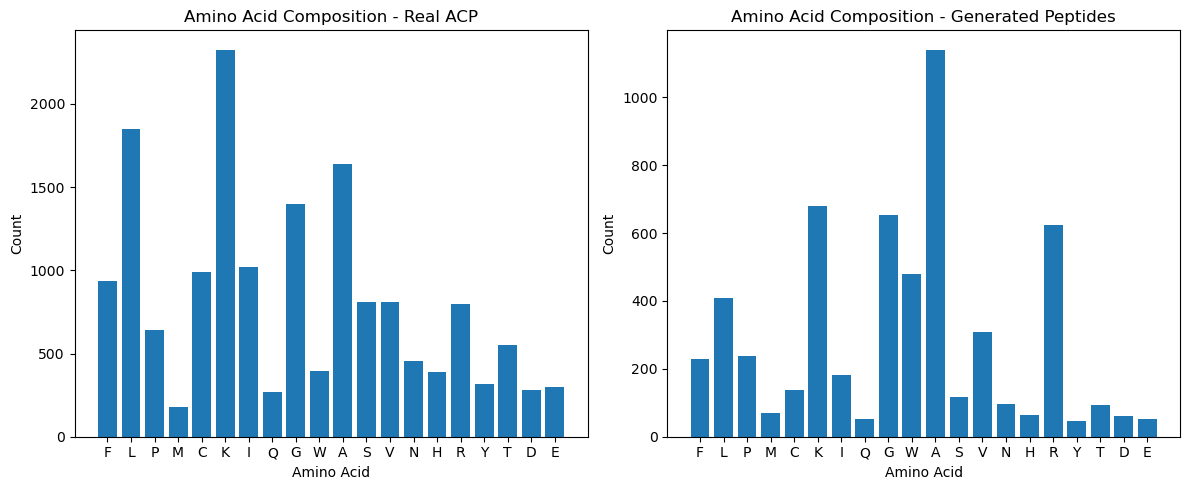

In [3]:
from Bio import SeqIO
import matplotlib.pyplot as plt
from collections import OrderedDict

def plot_amino_acid_composition(ax, fasta_file, title, ordered_amino_acids):
    amino_acid_count = OrderedDict.fromkeys(ordered_amino_acids, 0)

    # Read sequences from the FASTA file
    sequences = [str(record.seq) for record in SeqIO.parse(fasta_file, "fasta")]

    # Count the occurrences of each amino acid
    for sequence in sequences:
        for amino_acid in sequence:
            if amino_acid in amino_acid_count:
                amino_acid_count[amino_acid] += 1

    # Plot the amino acid composition
    labels = list(amino_acid_count.keys())
    counts = list(amino_acid_count.values())
    
    ax.bar(labels, counts)
    ax.set_xlabel('Amino Acid')
    ax.set_ylabel('Count')
    ax.set_title(title)

# Replace file paths with the actual paths to your FASTA files
fasta_file_path1 = 'acp_pos_train.fasta'
fasta_file_path2 = 'final_screened.fasta'

# Read the first FASTA file to determine the order of residues
ordered_amino_acids = []
for record in SeqIO.parse(fasta_file_path1, "fasta"):
    for amino_acid in str(record.seq):
        if amino_acid not in ordered_amino_acids:
            ordered_amino_acids.append(amino_acid)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot amino acid composition for the first file
plot_amino_acid_composition(axes[0], fasta_file_path1, 'Amino Acid Composition - Real ACP', ordered_amino_acids)

# Plot amino acid composition for the second file
plot_amino_acid_composition(axes[1], fasta_file_path2, 'Amino Acid Composition - Generated Peptides', ordered_amino_acids)

# Adjust layout and show the plot
plt.tight_layout()
fig.savefig("amino_acid_composition.pdf", format="pdf",dpi=300)
plt.show()

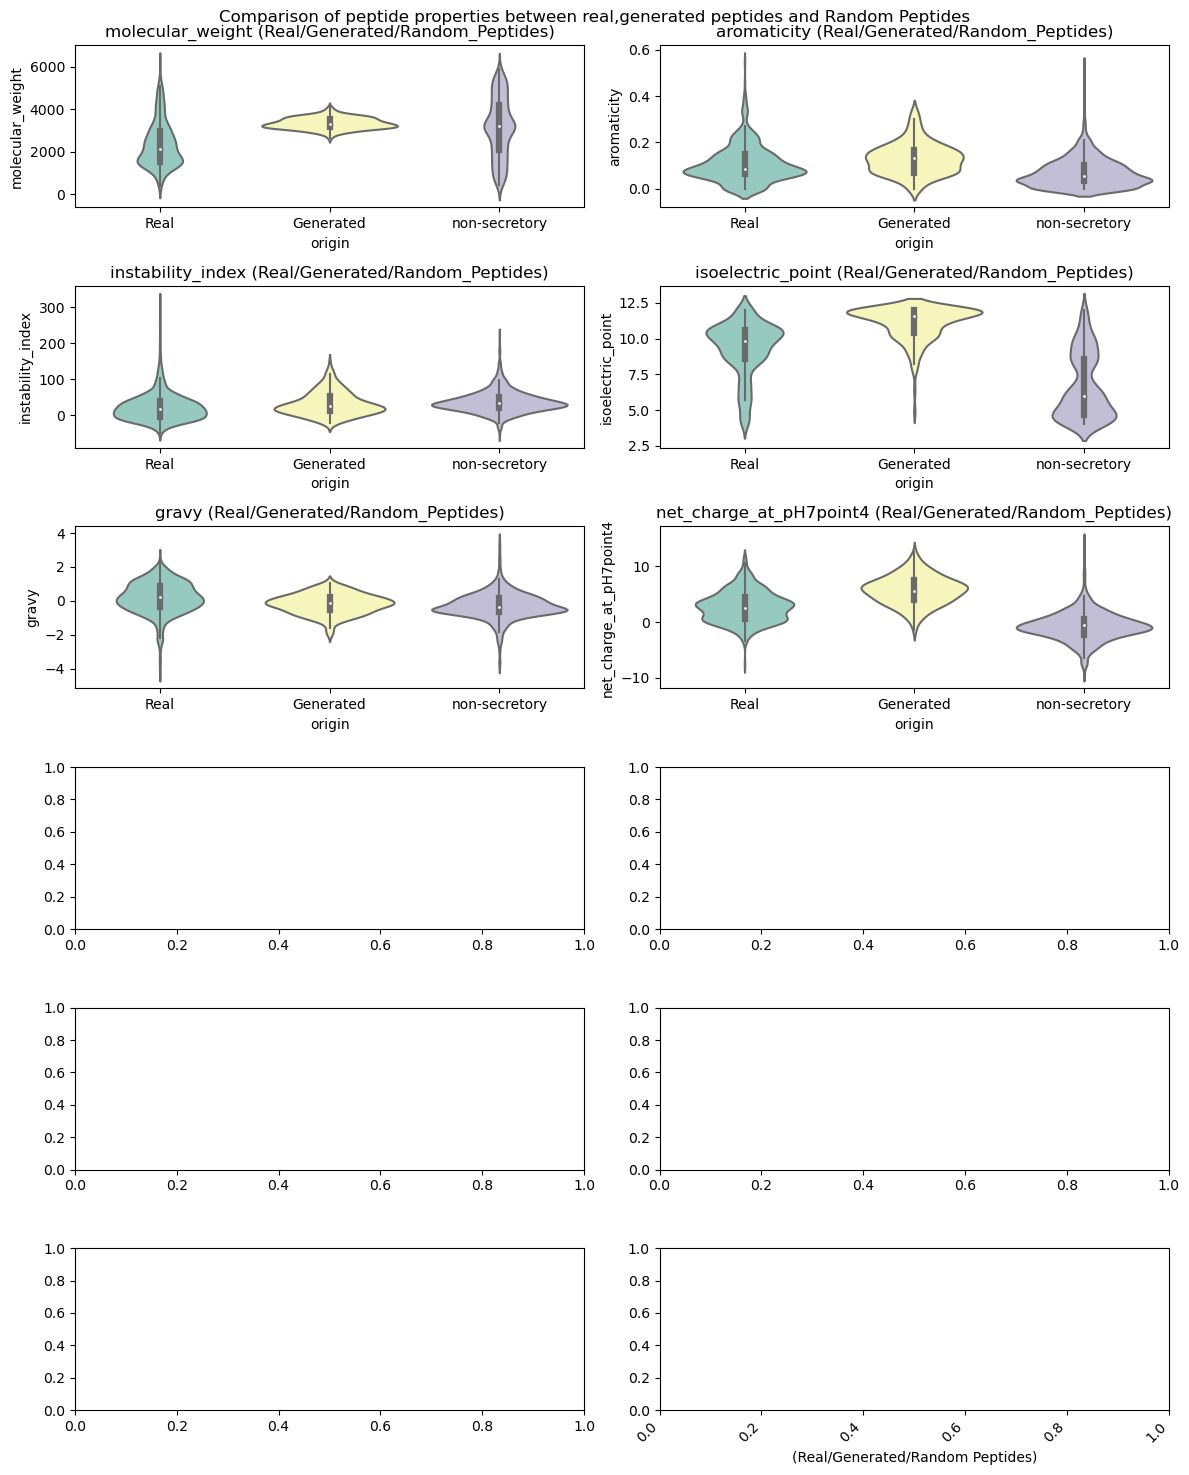

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def calculate_peptide_properties(sequences):
    """
    Calculates various physicochemical properties for a list of peptide sequences.

    Args:
        sequences: A list of strings representing peptide sequences.

    Returns:
        A pandas DataFrame containing the calculated properties for each peptide.
    """
    properties = []
    for seq in sequences:
        protein_analysis = ProteinAnalysis(seq)
        properties.append({
            "sequence": seq,
            "aa_counts": protein_analysis.count_amino_acids(),
            "aa_percentages": protein_analysis.get_amino_acids_percent(),
            "molecular_weight": protein_analysis.molecular_weight(),
            "aromaticity": protein_analysis.aromaticity(),
            "instability_index": protein_analysis.instability_index(),
            "isoelectric_point": protein_analysis.isoelectric_point(),
            "gravy": protein_analysis.gravy(),
            "net_charge_at_pH7point4": protein_analysis.charge_at_pH(7.4),
            #"sequence_length": protein_analysis.length(),  # Change variable name
        })
    return pd.DataFrame(properties)

def load_and_process_fasta(fasta_path):
    """
    Loads peptide sequences from a FASTA file and calculates their properties.

    Args:
        fasta_path: Path to the FASTA file.

    Returns:
        A pandas DataFrame containing the peptide sequences and their properties.
    """
    with open(fasta_path, "r") as f:
        sequences = [line.strip() for line in f if not line.startswith(">")]
    return calculate_peptide_properties(sequences)

def visualize_peptide_properties(real_data, generated_data,random_samples, properties_to_plot):
    # Add a new column 'origin' to indicate the origin of the data
    real_data['origin'] = 'Real'
    generated_data['origin'] = 'Generated'
    random_samples['origin'] = 'non-secretory'
    #breast_data['origin'] = 'breast'
    #lung_data['origin'] = 'lung'

    # Concatenate the dataframes
    combined_data = pd.concat([real_data, generated_data,random_samples])

    n_rows = len(properties_to_plot)
    n_cols = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 15))
    for i, prop in enumerate(properties_to_plot):
        sns.violinplot(
            x='origin',  # Use the 'origin' column as x variable
            y=prop,
            showmeans=True,
            data=combined_data,
            ax=axes[i // n_cols, i % n_cols],
            palette='Set3',
        )
        axes[i // n_cols, i % n_cols].set_title(f"{prop} (Real/Generated/Random_Peptides)")

    fig.suptitle("Comparison of peptide properties between real,generated peptides and Random Peptides")
    plt.xlabel("(Real/Generated/Random Peptides)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Define file paths and properties to plot
real_fasta_path = "acp_pos_train.fasta"
generated_fasta_path = "final_screened.fasta"
#breast_fasta_path = "/home/sadik/amp_gan/Evaluate/breast.fasta"
#lung_fasta_path = "/home/sadik/amp_gan/Evaluate/lung.fasta"
random_fasta_path = "Non_ACP_new.fasta"
properties_to_plot = ["molecular_weight","aromaticity","instability_index", "isoelectric_point", "gravy", "net_charge_at_pH7point4"]

# Load and process data
real_data = load_and_process_fasta(real_fasta_path)
generated_data = load_and_process_fasta(generated_fasta_path)
#breast_data = load_and_process_fasta(breast_fasta_path)
#lung_data = load_and_process_fasta(lung_fasta_path)
random_samples_data = load_and_process_fasta(random_fasta_path)

# Visualize the comparison
visualize_peptide_properties(real_data, generated_data, random_samples_data, properties_to_plot)

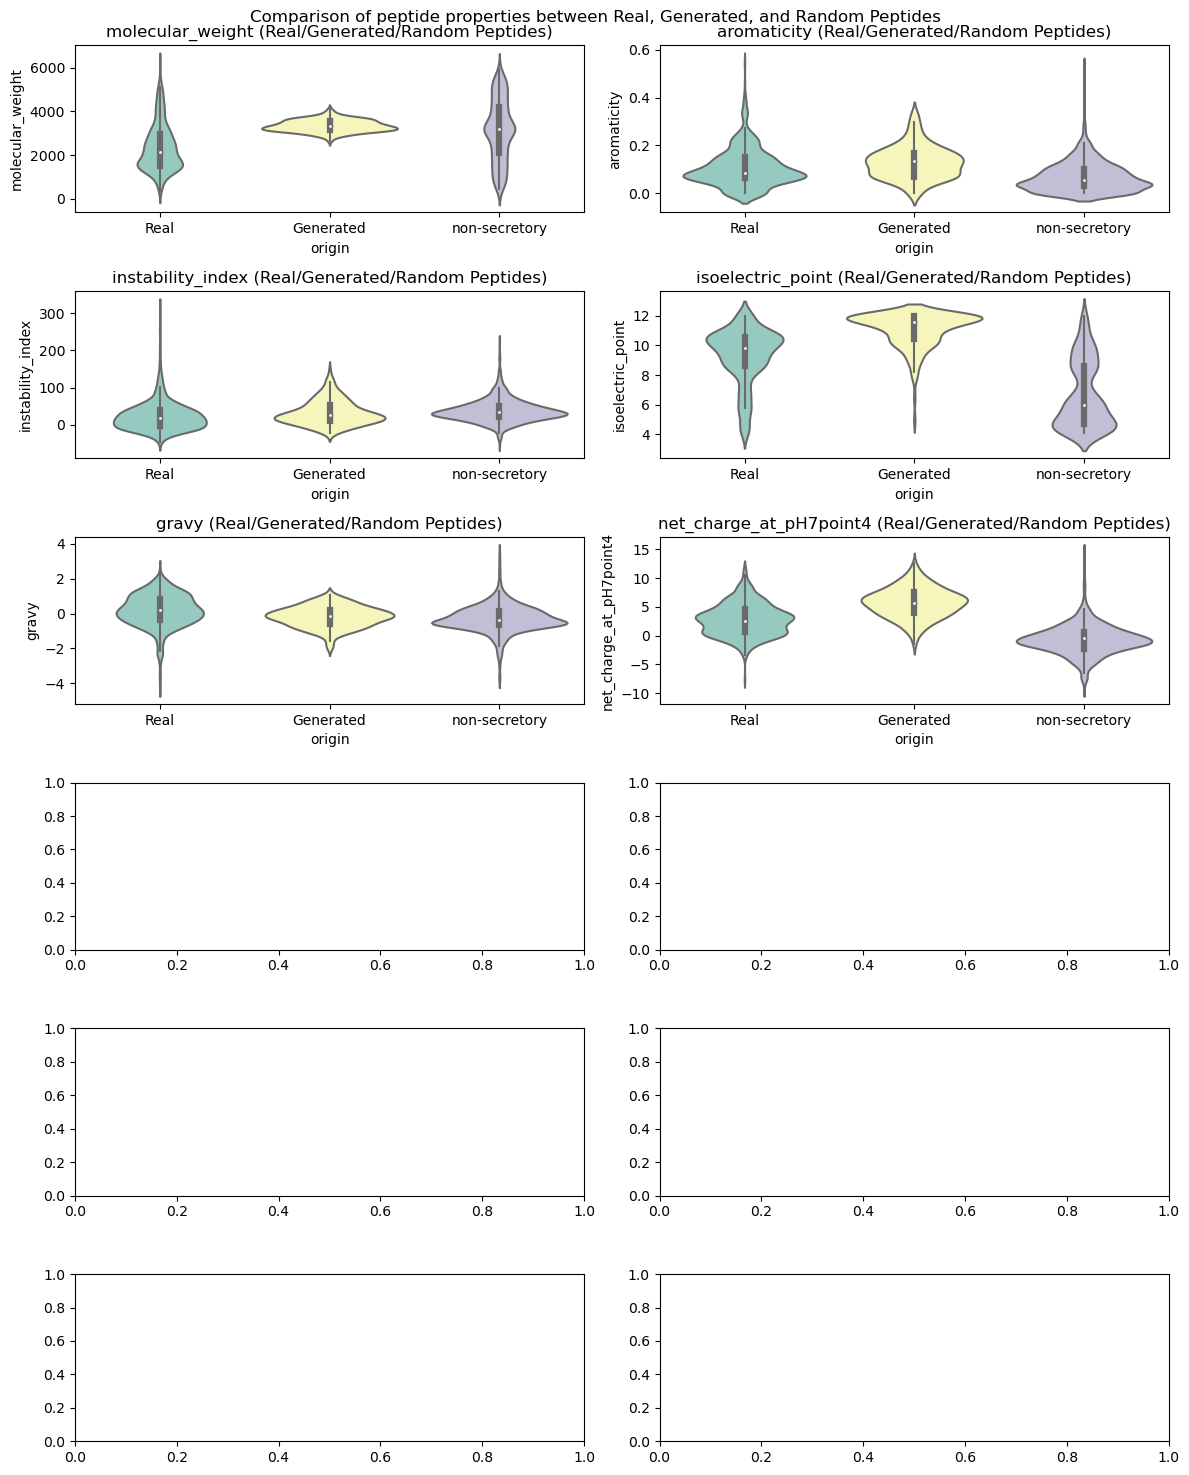

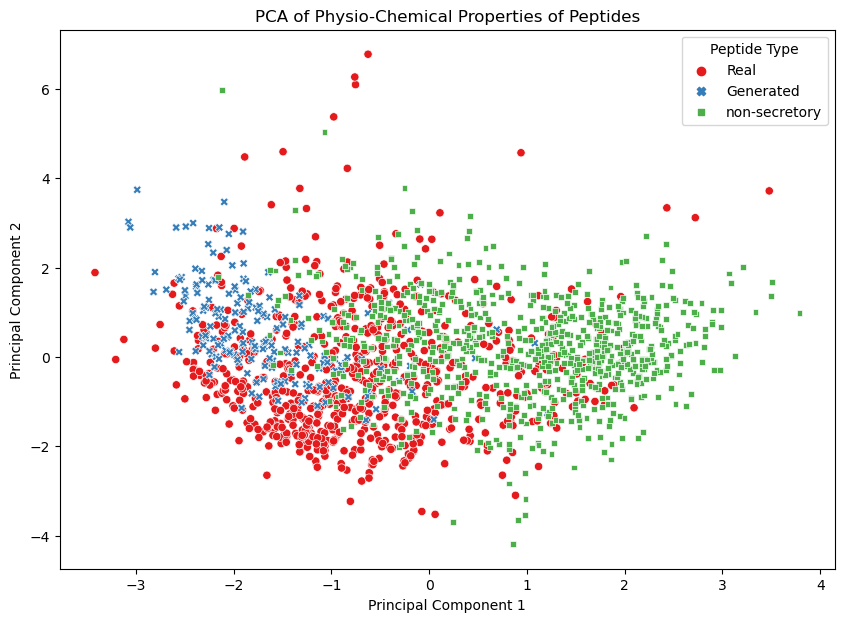

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def calculate_peptide_properties(sequences):
    """
    Calculates various physicochemical properties for a list of peptide sequences.

    Args:
        sequences: A list of strings representing peptide sequences.

    Returns:
        A pandas DataFrame containing the calculated properties for each peptide.
    """
    properties = []
    for seq in sequences:
        protein_analysis = ProteinAnalysis(seq)
        properties.append({
            "sequence": seq,
            "molecular_weight": protein_analysis.molecular_weight(),
            "aromaticity": protein_analysis.aromaticity(),
            "instability_index": protein_analysis.instability_index(),
            "isoelectric_point": protein_analysis.isoelectric_point(),
            "gravy": protein_analysis.gravy(),
            "net_charge_at_pH7point4": protein_analysis.charge_at_pH(7.4),
        })
    return pd.DataFrame(properties)

def load_and_process_fasta(fasta_path):
    """
    Loads peptide sequences from a FASTA file and calculates their properties.

    Args:
        fasta_path: Path to the FASTA file.

    Returns:
        A pandas DataFrame containing the peptide sequences and their properties.
    """
    with open(fasta_path, "r") as f:
        sequences = [line.strip() for line in f if not line.startswith(">")]
    return calculate_peptide_properties(sequences)

def visualize_peptide_properties(real_data, generated_data, random_samples, properties_to_plot):
    # Add a new column 'origin' to indicate the origin of the data
    real_data['origin'] = 'Real'
    generated_data['origin'] = 'Generated'
    random_samples['origin'] = 'non-secretory'

    # Concatenate the dataframes
    combined_data = pd.concat([real_data, generated_data, random_samples])

    n_rows = len(properties_to_plot)
    n_cols = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 15))
    for i, prop in enumerate(properties_to_plot):
        sns.violinplot(
            x='origin',  # Use the 'origin' column as x variable
            y=prop,
            showmeans=True,
            data=combined_data,
            ax=axes[i // n_cols, i % n_cols],
            palette='Set3',
        )
        axes[i // n_cols, i % n_cols].set_title(f"{prop} (Real/Generated/Random Peptides)")

    fig.suptitle("Comparison of peptide properties between Real, Generated, and Random Peptides")
    plt.tight_layout()
    plt.show()

def plot_pca(real_data, generated_data, random_samples, properties_to_plot):
    # Add a new column 'origin' to indicate the origin of the data
    real_data['origin'] = 'Real'
    generated_data['origin'] = 'Generated'
    random_samples['origin'] = 'non-secretory'

    # Concatenate the dataframes
    combined_data = pd.concat([real_data, generated_data, random_samples])

    # Extract the features and the labels
    X = combined_data[properties_to_plot]
    y = combined_data['origin']

    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform PCA
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(X_scaled)

    # Create a DataFrame with the PCA results
    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
    pca_df['origin'] = y.values

    # Plot the PCA results
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='origin', style='origin', palette='Set1')
    plt.title('PCA of Physio-Chemical Properties of Peptides')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Peptide Type')
    plt.show()

# Define file paths and properties to plot
real_fasta_path = "acp_pos_train.fasta"
generated_fasta_path = "final_screened.fasta"
random_fasta_path = "Non_ACP_new.fasta"
properties_to_plot = ["molecular_weight", "aromaticity", "instability_index", "isoelectric_point", "gravy", "net_charge_at_pH7point4"]

# Load and process data
real_data = load_and_process_fasta(real_fasta_path)
generated_data = load_and_process_fasta(generated_fasta_path)
random_samples_data = load_and_process_fasta(random_fasta_path)

# Visualize the comparison
visualize_peptide_properties(real_data, generated_data, random_samples_data, properties_to_plot)

# Plot PCA
plot_pca(real_data, generated_data, random_samples_data, properties_to_plot)

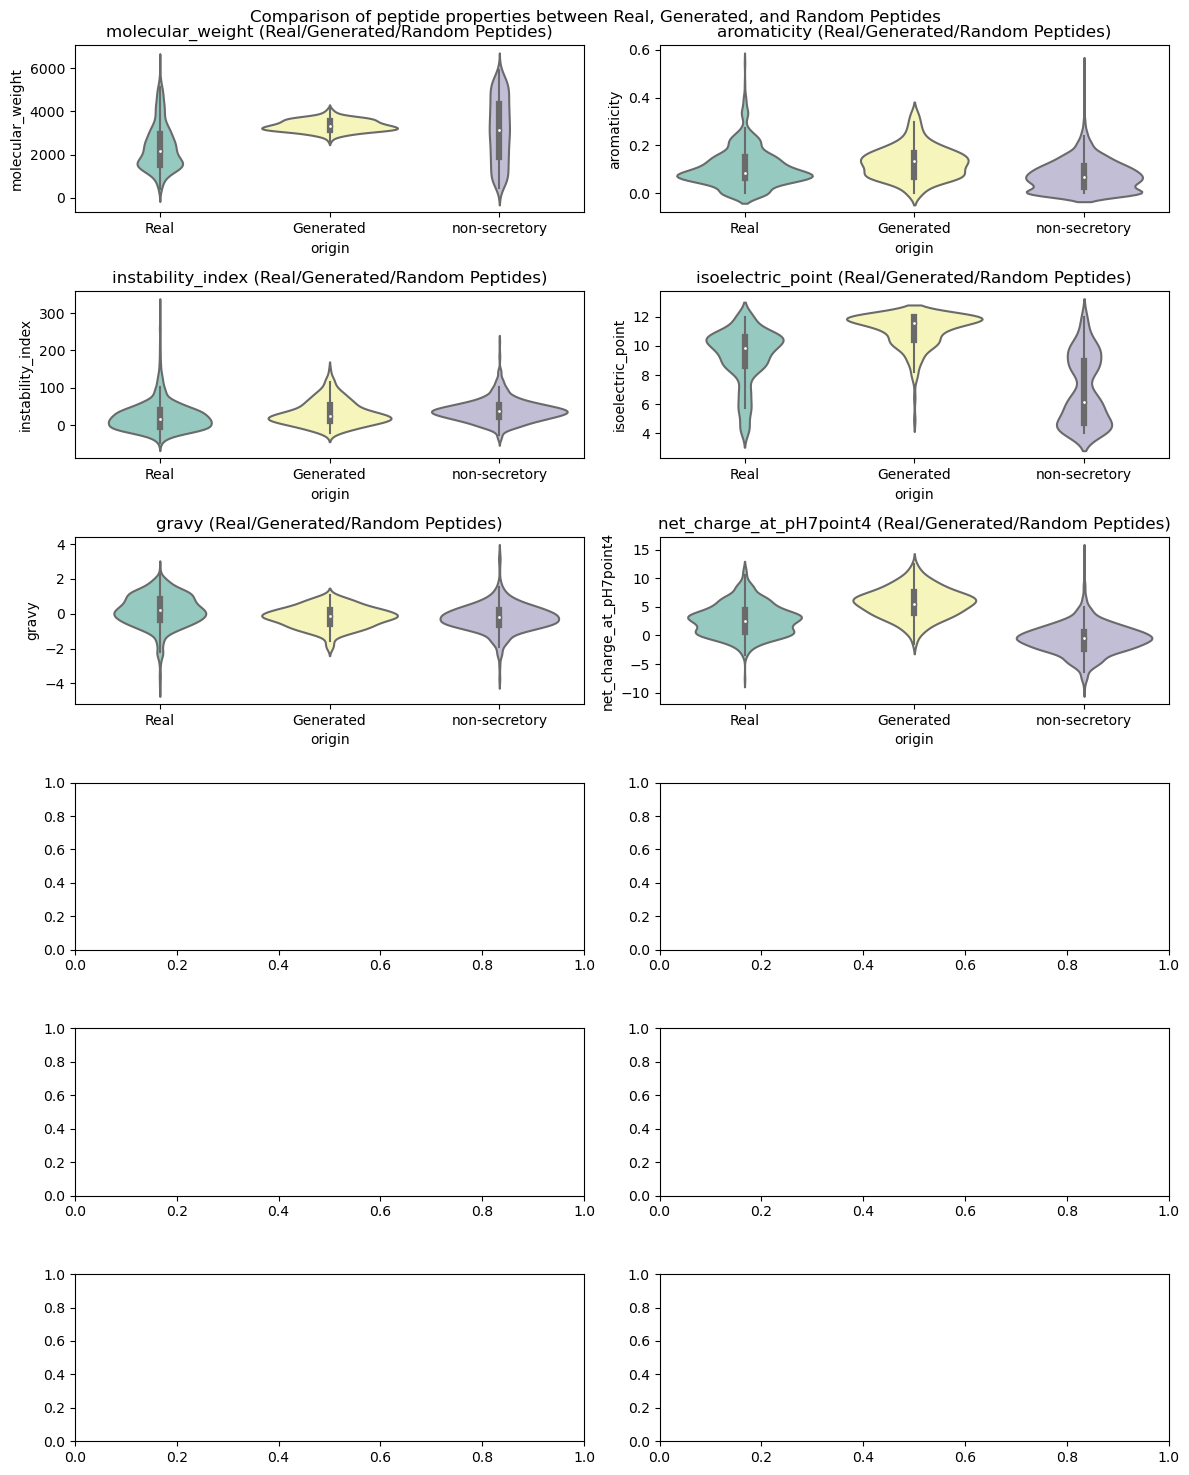

/home/sadik/anaconda3/envs/reset/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/home/sadik/anaconda3/envs/reset/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


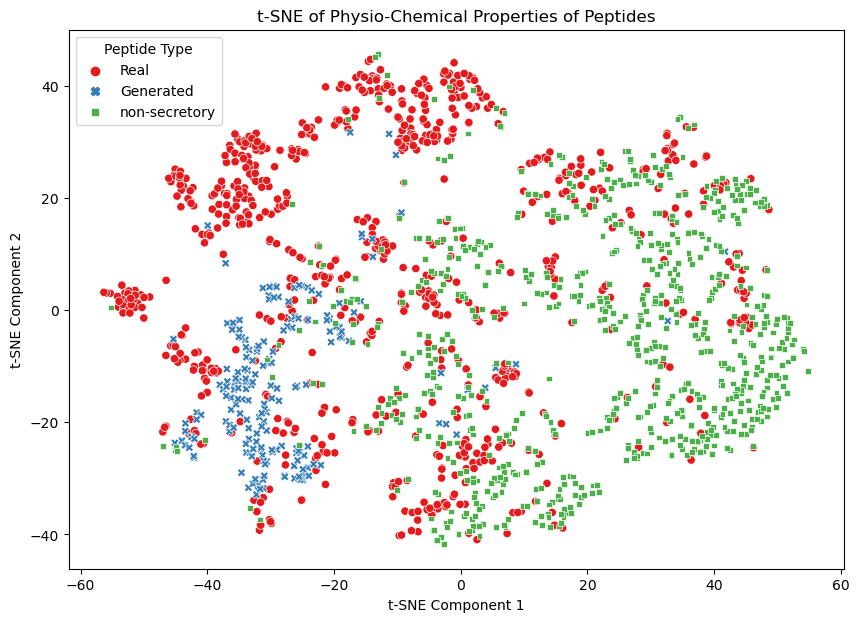

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

def calculate_peptide_properties(sequences):
    """
    Calculates various physicochemical properties for a list of peptide sequences.

    Args:
        sequences: A list of strings representing peptide sequences.

    Returns:
        A pandas DataFrame containing the calculated properties for each peptide.
    """
    properties = []
    for seq in sequences:
        protein_analysis = ProteinAnalysis(seq)
        properties.append({
            "sequence": seq,
            "molecular_weight": protein_analysis.molecular_weight(),
            "aromaticity": protein_analysis.aromaticity(),
            "instability_index": protein_analysis.instability_index(),
            "isoelectric_point": protein_analysis.isoelectric_point(),
            "gravy": protein_analysis.gravy(),
            "net_charge_at_pH7point4": protein_analysis.charge_at_pH(7.4),
        })
    return pd.DataFrame(properties)

def load_and_process_fasta(fasta_path):
    """
    Loads peptide sequences from a FASTA file and calculates their properties.

    Args:
        fasta_path: Path to the FASTA file.

    Returns:
        A pandas DataFrame containing the peptide sequences and their properties.
    """
    with open(fasta_path, "r") as f:
        sequences = [line.strip() for line in f if not line.startswith(">")]
    return calculate_peptide_properties(sequences)

def visualize_peptide_properties(real_data, generated_data, random_samples, properties_to_plot):
    # Add a new column 'origin' to indicate the origin of the data
    real_data['origin'] = 'Real'
    generated_data['origin'] = 'Generated'
    random_samples['origin'] = 'non-secretory'

    # Concatenate the dataframes
    combined_data = pd.concat([real_data, generated_data, random_samples])

    n_rows = len(properties_to_plot)
    n_cols = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 15))
    for i, prop in enumerate(properties_to_plot):
        sns.violinplot(
            x='origin',  # Use the 'origin' column as x variable
            y=prop,
            showmeans=True,
            data=combined_data,
            ax=axes[i // n_cols, i % n_cols],
            palette='Set3',
        )
        axes[i // n_cols, i % n_cols].set_title(f"{prop} (Real/Generated/Random Peptides)")

    fig.suptitle("Comparison of peptide properties between Real, Generated, and Random Peptides")
    plt.tight_layout()
    plt.show()

def plot_tsne(real_data, generated_data, random_samples, properties_to_plot):
    # Add a new column 'origin' to indicate the origin of the data
    real_data['origin'] = 'Real'
    generated_data['origin'] = 'Generated'
    random_samples['origin'] = 'non-secretory'

    # Concatenate the dataframes
    combined_data = pd.concat([real_data, generated_data, random_samples])

    # Extract the features and the labels
    X = combined_data[properties_to_plot]
    y = combined_data['origin']

    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(X_scaled)

    # Create a DataFrame with the t-SNE results
    tsne_df = pd.DataFrame(data=tsne_results, columns=['TSNE1', 'TSNE2'])
    tsne_df['origin'] = y.values

    # Plot the t-SNE results
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='origin', style='origin', palette='Set1')
    plt.title('t-SNE of Physio-Chemical Properties of Peptides')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(title='Peptide Type')
    plt.show()

# Define file paths and properties to plot
real_fasta_path = "acp_pos_train.fasta"
generated_fasta_path = "final_screened.fasta"
random_fasta_path = "non_acp_neg_train.fasta"
properties_to_plot = ["molecular_weight", "aromaticity", "instability_index", "isoelectric_point", "gravy", "net_charge_at_pH7point4"]

# Load and process data
real_data = load_and_process_fasta(real_fasta_path)
generated_data = load_and_process_fasta(generated_fasta_path)
random_samples_data = load_and_process_fasta(random_fasta_path)

# Visualize the comparison
visualize_peptide_properties(real_data, generated_data, random_samples_data, properties_to_plot)

# Plot t-SNE
plot_tsne(real_data, generated_data, random_samples_data, properties_to_plot)

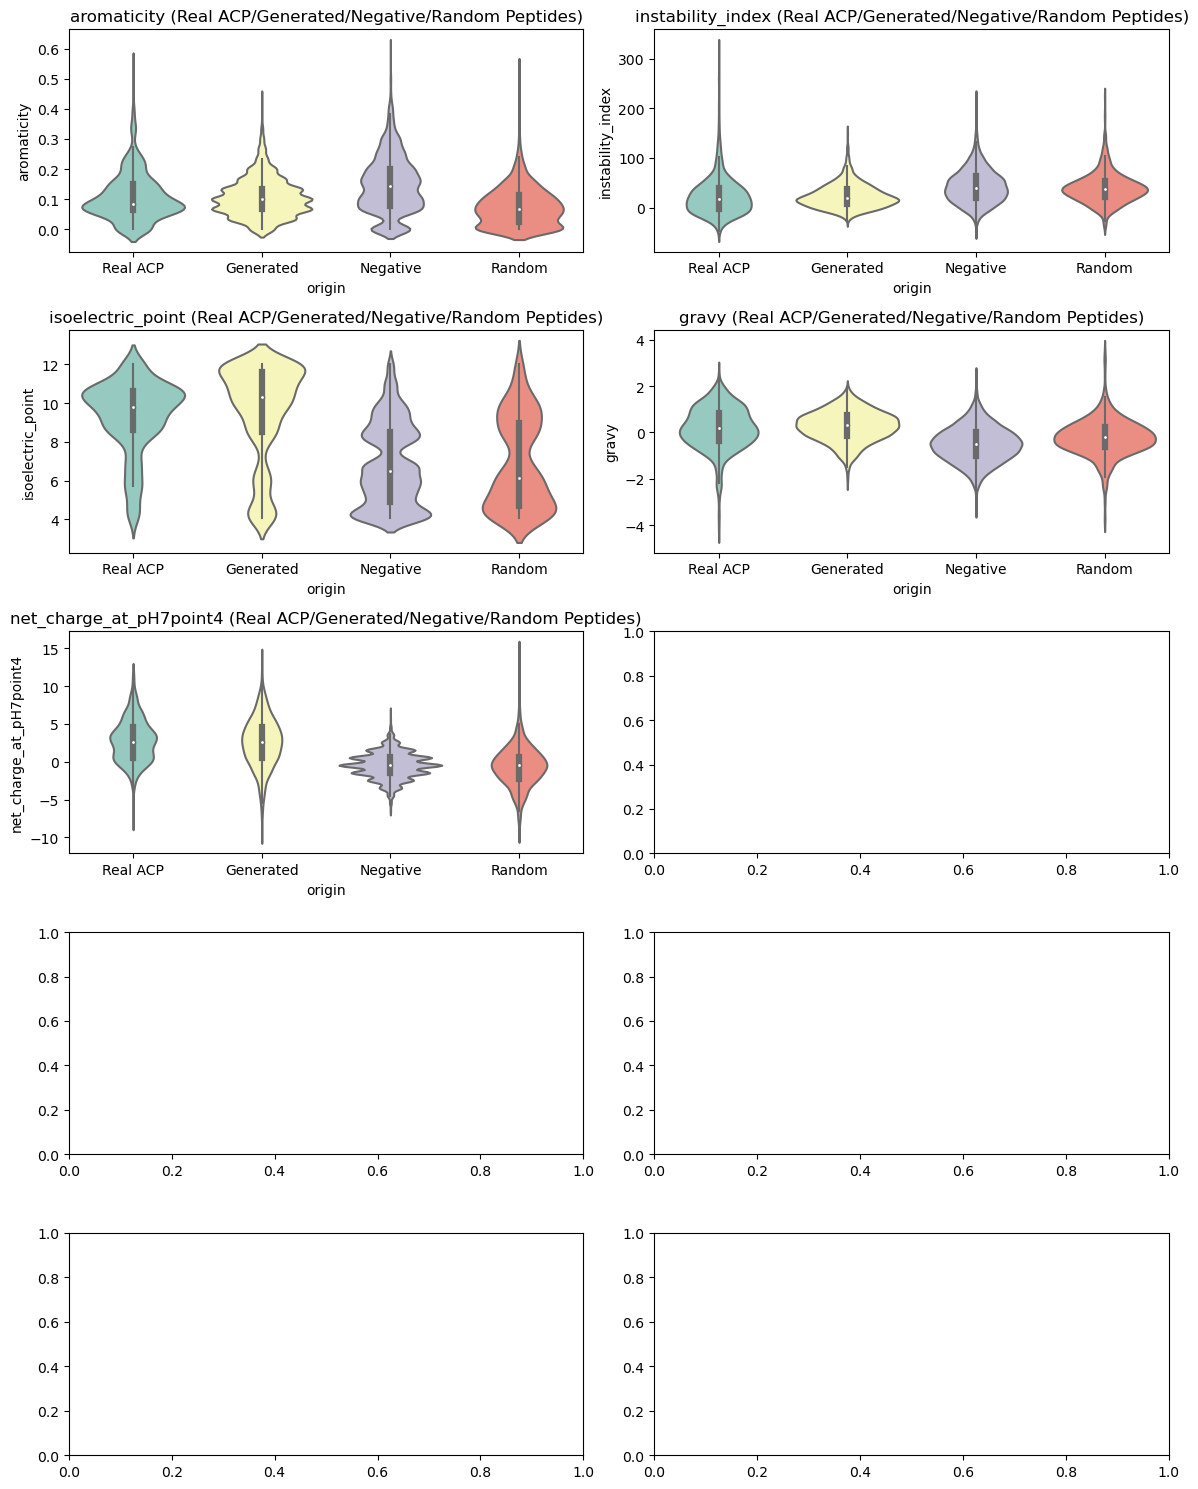

NameError: name 'negative' is not defined

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from modlamp.sequences import Random

def calculate_peptide_properties(sequences):
    """
    Calculates various physicochemical properties for a list of peptide sequences.

    Args:
        sequences: A list of strings representing peptide sequences.

    Returns:
        A pandas DataFrame containing the calculated properties for each peptide.
    """
    properties = []
    for seq in sequences:
        protein_analysis = ProteinAnalysis(seq)
        properties.append({
            "sequence": seq,
            "aromaticity": protein_analysis.aromaticity(),
            "instability_index": protein_analysis.instability_index(),
            "isoelectric_point": protein_analysis.isoelectric_point(),
            "gravy": protein_analysis.gravy(),
            "net_charge_at_pH7point4": protein_analysis.charge_at_pH(7.4),
        })
    return pd.DataFrame(properties)

def load_and_process_fasta(fasta_path):
    """
    Loads peptide sequences from a FASTA file and calculates their properties.

    Args:
        fasta_path: Path to the FASTA file.

    Returns:
        A pandas DataFrame containing the peptide sequences and their properties.
    """
    with open(fasta_path, "r") as f:
        sequences = [line.strip() for line in f if not line.startswith(">")]
    return calculate_peptide_properties(sequences)

def generate_random_peptides(num_peptides, length_range=(10, 30)):
    """
    Generates a list of random peptide sequences using modlamp.

    Args:
        num_peptides: Number of random peptides to generate.
        length_range: Tuple specifying the range of peptide lengths.

    Returns:
        A pandas DataFrame containing the generated random peptides and their properties.
    """
    rand = Random(num_peptides, length_range[0], length_range[1])
    rand.generate_sequences()
    return calculate_peptide_properties(rand.sequences)

def visualize_peptide_properties(real_data, generated_data, random_samples, negative_data, properties_to_plot):
    # Add a new column 'origin' to indicate the origin of the data
    real_data['origin'] = 'Real ACP'
    generated_data['origin'] = 'Generated'
    negative_data['origin'] = 'Negative'
    random_samples['origin'] = 'Random'

    # Concatenate the dataframes
    combined_data = pd.concat([real_data, generated_data, negative_data, random_samples])

    n_rows = len(properties_to_plot)
    n_cols = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 15))
    for i, prop in enumerate(properties_to_plot):
        sns.violinplot(
            x='origin',  # Use the 'origin' column as x variable
            y=prop,
            showmeans=True,
            data=combined_data,
            ax=axes[i // n_cols, i % n_cols],
            palette='Set3',
        )
        axes[i // n_cols, i % n_cols].set_title(f"{prop} (Real ACP/Generated/Negative/Random Peptides)")

    #fig.suptitle("Comparison of peptide properties between Real, Generated, Negative and Random Peptides")
    plt.tight_layout()
    plt.show()

def plot_tsne(real_data, generated_data,negative_data, random_samples, properties_to_plot):
    # Add a new column 'origin' to indicate the origin of the data
    real_data['origin'] = 'Real ACP'
    generated_data['origin'] = 'Generated'
    negative_data['origin'] = 'Negative'
    random_samples['origin'] = 'Random'

    # Concatenate the dataframes
    combined_data = pd.concat([real_data, generated_data, negative_data, random_samples])
 
    # Extract the features and the labels
    X = combined_data[properties_to_plot]
    y = combined_data['origin']

    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(X_scaled)

    # Create a DataFrame with the t-SNE results
    tsne_df = pd.DataFrame(data=tsne_results, columns=['TSNE1', 'TSNE2'])
    tsne_df['origin'] = y.values

    # Plot the t-SNE results
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='origin', style='origin', palette='Set1')
    plt.title('t-SNE Plot of the  Physio-Chemical Properties of Real ACPs, Generated, Negative and Random Peptides')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(title='Peptide Type')
    plt.savefig("tsne.pdf", format="pdf",dpi=300)
    plt.show()


# Define file paths and properties to plot
real_fasta_path = "acp_pos_train.fasta"
generated_fasta_path = "final_generated_seq.fasta"
negative_fasta_path = "non_acp_neg_train.fasta" 
properties_to_plot = ["aromaticity", "instability_index", "isoelectric_point", "gravy", "net_charge_at_pH7point4"]

# Load and process data
real_data = load_and_process_fasta(real_fasta_path)
generated_data = load_and_process_fasta(generated_fasta_path)
negative_data = load_and_process_fasta(negative_fasta_path)
random_samples_data = generate_random_peptides(num_peptides=8000, length_range=(10, 20))

# Visualize the comparison
visualize_peptide_properties(real_data, generated_data,negative_data, random_samples_data, properties_to_plot)

# Plot t-SNE
plot_tsne(real_data, generated_data,negative,random_samples_data, properties_to_plot)

In [ ]:
from Bio import SeqIO
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# Define the file paths
train_file = "non_acp_neg_train.fasta"
test_file = "non_acp_neg_val.fasta"
generated_file = "Non_ACP_GAN_filtered_300.fasta"

# Read sequences from the FASTA files
def read_fasta(file_path):
    sequences = set()
    for record in SeqIO.parse(file_path, "fasta"):
        sequences.add(str(record.seq))
    return sequences

# Read sequences from the three files
train_sequences = read_fasta(train_file)
test_sequences = read_fasta(test_file)
generated_sequences = read_fasta(generated_file)

# Find common sequences
common_sequences_train_test = train_sequences.intersection(test_sequences)
common_sequences_train_generated = train_sequences.intersection(generated_sequences)
common_sequences_test_generated = test_sequences.intersection(generated_sequences)
common_sequences_all = train_sequences.intersection(test_sequences, generated_sequences)

# Get the number of common sequences
num_common_sequences_train_test = len(common_sequences_train_test)
num_common_sequences_train_generated = len(common_sequences_train_generated)
num_common_sequences_test_generated = len(common_sequences_test_generated)
num_common_sequences_all = len(common_sequences_all)

# Print the number of common sequences
print(f'Number of common sequences in Train and Test: {num_common_sequences_train_test}')
print(f'Number of common sequences in Train and Generated: {num_common_sequences_train_generated}')
print(f'Number of common sequences in Test and Generated: {num_common_sequences_test_generated}')
print(f'Number of common sequences in Train, Test, and Generated: {num_common_sequences_all}')

# Create a Venn diagram
plt.figure(figsize=(8, 8))
venn_diagram = venn3(
    subsets=(len(train_sequences - common_sequences_all),
             len(test_sequences - common_sequences_all),
             len(common_sequences_train_test - common_sequences_all),
             len(generated_sequences - common_sequences_all),
             len(common_sequences_train_generated - common_sequences_all),
             len(common_sequences_test_generated - common_sequences_all),
             len(common_sequences_all)),
    set_labels=('Train', 'Test', 'Generated')
)

# Display the plot
plt.title("Common Sequences Venn Diagram for Non-ACP")
plt.show()

In [ ]:
#DATASET CREATION FOR THE trainign a model using a gan genertaed dataset
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis as PA
from modlamp.descriptors import PeptideDescriptor, GlobalDescriptor
from sklearn.model_selection import train_test_split,KFold
import pandas as pd
import os, re, math, platform
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import linalg as la
import os
import random
import warnings
warnings.filterwarnings('ignore')
import random
from fea_extract import read_fasta,insert_AAC,insert_DPC,insert_CKSAAGP,insert_CTD,insert_PAAC,insert_AAI,insert_GTPC,insert_QSO,insert_AAE,insert_PSAAC,insert_word2int,insert_ASDC
from tools import del_data
seed = 10
from pathlib import Path
Path('./results/process_data/').mkdir(exist_ok=True,parents=True)
Path('./results/balance/').mkdir(exist_ok=True,parents=True)

In [ ]:
# Parsing a fasta or csv file
def del_data(inFile):
    seq = read_fasta(inFile)
    seqname = seq.to_numpy()
    newseq = []
    j = seqname.shape[0]
    for i in range(j):
        if 6 <= len(seqname[i][1])<=100:
            newseq.append(seqname[i])
    newseq = np.array(newseq)
    print('shape of data：', newseq.shape)
    newseq = pd.DataFrame(data=newseq, columns=["Id", "Sequence"])
    return newseq

In [ ]:
#now combine previosu training, generated and validation dataset to create new anticancer and antimicrobial peptide dataset
def combine_fasta_files(input_files, output_file):
    combined_seqs = {}
    
    for file in input_files:
        with open(file, 'r') as f:
            lines = f.readlines()
            header = None
            sequence = ''
            for line in lines:
                if line.startswith('>'):
                    if header is not None:
                        combined_seqs[header] = sequence
                    header = line.strip()
                    sequence = ''
                else:
                    sequence += line.strip()
            if header is not None:
                combined_seqs[header] = sequence

    with open(output_file, 'w') as out:
        for header, sequence in combined_seqs.items():
            out.write(f"{header}\n{sequence}\n")

# Example Usage:
input_files = ['Non_ACP_GAN_filtered_300.fasta', 'non_acp_neg_train.fasta', 'non_acp_neg_val.fasta']
output_file = 'Non_ACP_new.fasta'

combine_fasta_files(input_files, output_file)

In [ ]:
seq_ACP =del_data('ACP_new.fasta')
seq_non_ACP =del_data('Non_ACP_new.fasta')

In [ ]:
from tools import pro_data
#Splitting a data to create a train and test data from this orginal dataset  #80%，20%
prefix = [seq_ACP,seq_non_ACP]
Prefix = ['seq_ACP','seq_non_ACP']
for i in range(2):
    df_train,df_test = train_test_split(prefix[i],random_state=seed,test_size=.2)
    df_train.to_csv(os.path.join( "data/train/{:s}_train.csv".format(Prefix[i])), index=False)
    df_test.to_csv(os.path.join("data/test/{:s}_test.csv".format(Prefix[i])), index=False)
    print("Done!")

In [ ]:
#saving file to csv
train_sets = {
    lab:pd.read_csv('data/train/{:s}_train.csv'.format(lab))
    for lab in ['seq_ACP','seq_non_ACP']
}
test_sets = {
    lab:pd.read_csv('data/test/{:s}_test.csv'.format(lab))
    for lab in ['seq_ACP','seq_non_ACP']
}
train_sets['seq_ACP'].loc[:, 'Label'] = 1 #set label for classes
train_sets['seq_non_ACP'].loc[:, 'Label'] = 0 #set label for classes
test_sets['seq_ACP'].loc[:, 'Label'] = 1
test_sets['seq_non_ACP'].loc[:, 'Label'] = 0

#create a dataset, train and test dataset
all_train = pd.concat([train_sets['seq_ACP'],train_sets['seq_non_ACP']],ignore_index='ignore')
all_test = pd.concat([test_sets['seq_ACP'],test_sets['seq_non_ACP']],ignore_index='ignore')
X_train = all_train.iloc[:,0:2]
X_test = all_test.iloc[:,0:2]
y_train = all_train['Label']
y_test = all_test["Label"]
X_test.to_csv('data/test/X_test.csv',index = False)
y_test.to_csv('data/test/y_test.csv',index = False)
X_train.to_csv('data/train/X_train.csv',index = False)
y_train.to_csv('data/train/y_train.csv',index = False)

In [ ]:
#define a encoding for training
insert_list=[insert_AAC,insert_DPC,insert_CKSAAGP,insert_PSAAC,insert_CTD,insert_GTPC,
             insert_QSO,insert_AAE,insert_AAI,insert_ASDC,insert_PAAC,pro_data]
insert_str=["insert_AAC","insert_DPC","insert_CKSAAGP","insert_PSAAC","insert_CTD",
            "insert_GTPC","insert_QSO","insert_AAE","insert_AAI","insert_ASDC","insert_PAAC",'insert_All_data']

In [ ]:
n = len(insert_list)
for j in range(n):
    print("encoding{}_{}".format(str(j),insert_str[j][7:]))
    X_test = pd.read_csv('data/test/X_test.csv')
    X_train = pd.read_csv('data/train/X_train.csv')
    df_seq_train = insert_list[j](X_train)
    df_seq_train.to_csv('results/process_data/train_{}.csv'.format(insert_str[j][7:]),index =False )
    df_seq_test = insert_list[j](X_test)
    df_seq_test.to_csv('results/process_data/test_{}.csv'.format(insert_str[j][7:]),index =False )

In [ ]:
from tools import padseq
X_test = pd.read_csv('data/test/X_test.csv')
X_train = pd.read_csv('data/train/X_train.csv')
new_seq_train = padseq(X_train)
new_seq_test = padseq(X_test)
word2_seq_train = insert_word2int(new_seq_train)
word2_seq_train.to_csv('results/process_data/train_word2int.csv',index=False)

word2_seq_test = insert_word2int(new_seq_test)
word2_seq_test.to_csv('results/process_data/test_word2int.csv',index=False)

In [ ]:
insert_list=[insert_AAC,insert_DPC,insert_CKSAAGP,insert_PSAAC,insert_CTD,insert_GTPC,
             insert_QSO,insert_AAE,insert_AAI,insert_ASDC,insert_PAAC]
insert_str=["insert_AAC","insert_DPC","insert_CKSAAGP","insert_PSAAC","insert_CTD",
            "insert_GTPC","insert_QSO","insert_AAE","insert_AAI","insert_ASDC","insert_PAAC"]